# Анализ лояльности пользователей Яндекс Афиши

### Цель проекта

Команда маркетинга хочет лучше понимать поведение пользователей. Для этого они просят вас провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:
- Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
- Оптимизировать маркетинговые бюджеты.
- Повысить общий уровень удержания клиентов.

### 1. Загрузка данных и их предобработка

---

**1.1:** SQL-запрос, выгружающий в датафрейм pandas необходимые данные. 

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [76]:
import pandas as pd
from sqlalchemy import create_engine
from datetime import datetime
import numpy as np
import re
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from phik import phik_matrix

In [77]:
load_dotenv(override=True) # автоматически ищет .env в текущей директории
    
connection_string = 'postgresql://{}:{}@{}:{}/{}?sslmode=require'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PASSWORD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME'),
) 

In [78]:
# создание соединения 
engine = create_engine(connection_string)

In [79]:
# извлечение результатов sql запроса
query = '''
WITH purchases_enriched AS (
  SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk as order_dt,
    p.created_ts_msk as order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (
      created_dt_msk::date
      - LAG(created_dt_msk::date) OVER (
          PARTITION BY user_id
          ORDER BY created_dt_msk
        )
    )::int AS days_since_prev,
    p.event_id,
    e.event_name_code as event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
  FROM afisha.purchases p
  INNER JOIN afisha.events e ON e.event_id = p.event_id
  LEFT JOIN afisha.city c ON c.city_id = e.city_id
  LEFT JOIN afisha.regions r ON r.region_id = c.region_id
  WHERE device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм'
)
SELECT *
FROM purchases_enriched
ORDER BY user_id ASC;
'''

In [80]:
df = pd.read_sql_query(query, con=engine)

---

**1.2:** Изучение общей информации о выгруженных данных.

---

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [82]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


###  Промежуточный вывод:
- типы данных соответствуют описанию
- можно провести понижение размерностей для экономии памяти в колонках: order_id, revenue, tickets_count, days_since_prev, event_id

---

###  2. Предобработка данных

---

**2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [83]:
df_rub_tenge_exch = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [84]:
df_rub_tenge_exch.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [85]:
# подготовка данных в столбцах времени
df['order_dt'] = pd.to_datetime(df['order_dt']).dt.normalize()
df_rub_tenge_exch['data'] = pd.to_datetime(df_rub_tenge_exch['data']).dt.normalize()

In [86]:
# Подтягиваем курс тенге к рублю на дату заказа
df = df.merge(
    df_rub_tenge_exch[['data', 'curs']],
    left_on='order_dt',
    right_on='data',
    how='left'
)

In [87]:
df['revenue_rub'] = np.where(
    df['currency_code'].eq('kzt'),
    df['revenue'] * df['curs'] / 100,
    df['revenue']
)

In [88]:
# удаление технических колонок
df = df.drop(columns=['data', 'curs'])

In [89]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


---

**2.2:** Проверка данных на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.

---

In [90]:
# 1) Проверка на пропуски
df.isna().sum() / len(df) * 100

user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
days_since_prev          7.547202
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.000000
city_name                0.000000
revenue_rub              0.000000
dtype: float64

### Анализ
- в столбце days_since_prev 7.5% пропусков. Доля пропусков существенная, удалять не будем. Оставляем как есть
- в двугих столбцах пропусков нет

Следловательно, выгрузка из SQL прошла успешно

In [91]:
# 2) Преобразование типов данных в колонках
'''
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
'''
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [92]:
# преобразования типов, понижение размерностей
def downcast_type(col_name: str, type_name: str):
    return pd.to_numeric(df[col_name], downcast=type_name)

In [93]:
col_to_int_downcast = ['order_id', 'tickets_count', 'event_id']

for col in col_to_int_downcast:
    df[col] = downcast_type(col, 'integer')

In [94]:
col_to_float_downcast = ['days_since_prev', 'revenue', 'revenue_rub']

for col in col_to_float_downcast:
    df[col] = downcast_type(col, 'float')

In [95]:
# преобразование дат для уменьшения избыточности
df['order_dt'] = df['order_dt'].dt.floor('D')   # оставляем только дату

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


### Изучение данных в ключевых столбцах

In [97]:
min(df['revenue'])

-90.76

- есть отрицательное значение прибыли revenue, это явно ошибка в данных

In [98]:
(df['revenue'] < 0).sum() / len(df) * 100

np.float64(0.13110308969722412)

- ошибочных данных по прибыли менее 0.2% Можно безболезненно удалить

In [99]:
df = df.drop(df[df['revenue'] < 0].index)

In [100]:
print((df['revenue'] < 0).sum() / len(df) * 100)
print((df['revenue_rub'] < 0).sum() / len(df) * 100) 

0.0
0.0


- ошибок теперь нет в revenue и revenue_rub

In [101]:
df['event_type_main'].unique()

<StringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str

- 'другое' - флаг отсутствия информации 

In [102]:
(df['event_type_main'] == 'другое').sum() / len(df) * 100

np.float64(22.586224718326843)

- доля отсутствующей информации в event_type_main : 22.6%

### Проверка на дубликаты 

In [103]:
# Проверка на яные дубликаты
df.duplicated().sum()  #  их нет

np.int64(0)

In [104]:
# проверка неявных дубликатов
df['event_type_main'].value_counts()

event_type_main
концерты    115275
театр        67321
другое       65552
спорт        21889
стендап      13393
выставки      4811
ёлки          1989
Name: count, dtype: int64

In [105]:
df['region_name'].value_counts()

region_name
Каменевский регион          91058
Североярская область        44035
Широковская область         16387
Медовская область           13900
Озернинский край            10476
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: count, Length: 81, dtype: int64

In [106]:
df['service_name'].value_counts()

service_name
Билеты без проблем        63294
Лови билет!               41088
Билеты в руки             40250
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17748
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5227
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                 

In [107]:
df['order_id'].nunique(), len(df)  # дублей по заказам нет

(290230, 290230)

In [108]:
df['currency_code'].unique()  # дублей нет

<StringArray>
['rub', 'kzt']
Length: 2, dtype: str

In [109]:
df['device_type_canonical'].unique()  # дублей нет

<StringArray>
['mobile', 'desktop']
Length: 2, dtype: str

- явных и неявных дублей не выявлено

### Нормализация строковых данных  

In [110]:
def to_snake_case(value):
    """Преобразует одно значение в snake_case."""
    if pd.isna(value):
        return value
    s = str(value).strip().lower()
    s = re.sub(r"[^\w\s-]", "", s, flags=re.UNICODE)  
    s = re.sub(r"[\s\-]+", "_", s)                  
    s = re.sub(r"_+", "_", s).strip("_") 
    return s

def normalize_columns_snake_case(df, columns):
    """Нормализует указанные столбцы DataFrame в snake_case."""
    df = df.copy()
    for col in columns:
        df[col] = df[col].apply(to_snake_case)
    return df

In [111]:
# для строковых данных уместно провести нормализацию к snake_case
df = normalize_columns_snake_case(df, ['region_name', 'city_name', 'service_name'])

### Проверка распределения численных данных и наличия в них выбросов


In [112]:
df.info()

<class 'pandas.DataFrame'>
Index: 290230 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290230 non-null  str           
 1   device_type_canonical  290230 non-null  str           
 2   order_id               290230 non-null  int32         
 3   order_dt               290230 non-null  datetime64[us]
 4   order_ts               290230 non-null  datetime64[us]
 5   currency_code          290230 non-null  str           
 6   revenue                290230 non-null  float64       
 7   tickets_count          290230 non-null  int8          
 8   days_since_prev        268329 non-null  float32       
 9   event_id               290230 non-null  int32         
 10  event_name             290230 non-null  str           
 11  event_type_main        290230 non-null  str           
 12  service_name           290230 non-null  str           
 13  

In [113]:
def discribe_analysis(column_to_analyse: pd.Series, qnt: float):
    extra_revenue_rub_bound = column_to_analyse.quantile(qnt)
    print(f'{qnt * 100} % значений менее {extra_revenue_rub_bound}')
    print('Минимальное значение: ', column_to_analyse.min())
    print('Медиана: ', column_to_analyse.median())
    print('Максимальное значение: ', column_to_analyse.max())
    print('Размах: ', column_to_analyse.max() - column_to_analyse.min())

In [114]:
# проверка распределения в данных
df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe()


,revenue_rub,tickets_count,days_since_prev
count,290230.000000,290230.000000,268329.000000
mean,556.304587,2.755149,3.224120
std,875.838948,1.170634,11.354673
min,0.000000,1.000000,0.000000
25%,114.610000,2.000000,0.000000
50%,352.080000,3.000000,0.000000
75%,802.250000,4.000000,1.000000
max,81174.540000,57.000000,148.000000


99.0 % значений менее 2628.4217390400004
Минимальное значение:  0.0
Медиана:  352.08
Максимальное значение:  81174.54
Размах:  81174.54


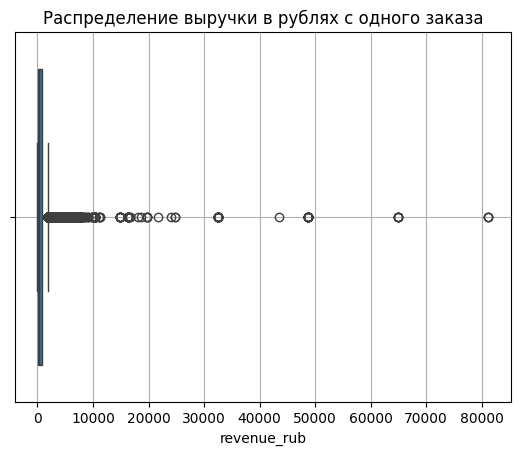

In [115]:
sns.boxplot(data=df, x='revenue_rub')
discribe_analysis(df['revenue_rub'], qnt=0.99)
plt.title('Распределение выручки в рублях с одного заказа')
plt.grid()

- выбросы в revenue_rub есть: 99.0 % значений менее 2628 при максимальном значении 81175. Медианное значение 352.08

99.0 % значений менее 6.0
Минимальное значение:  1
Медиана:  3.0
Максимальное значение:  57
Размах:  56


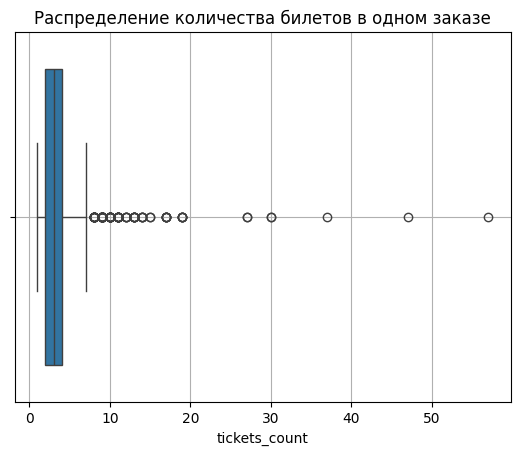

In [116]:
sns.boxplot(data=df, x='tickets_count')
discribe_analysis(df['tickets_count'], qnt=0.99)
plt.title('Распределение количества билетов в одном заказе')
plt.grid()

- в столбце tickets_count есть выбросы: 99.0 % значений менее 6.0 при максимальном значении 57. Медиана:  3.0

99.0 % значений менее 63.0
Минимальное значение:  0.0
Медиана:  0.0
Максимальное значение:  148.0
Размах:  148.0


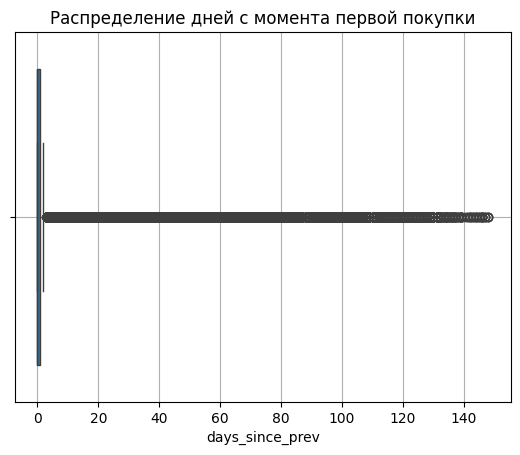

In [117]:
sns.boxplot(data=df, x='days_since_prev')
discribe_analysis(df['days_since_prev'], qnt=0.99)
plt.title('Распределение дней с момента первой покупки')
plt.grid()

- в столбце days_since_prev есть выбросы: 99.0 % значений менее 63.0 при максимальном значении 148. Медиана:  0.0

In [118]:
# Проведем фильтрацию значений для revenue_rub по 99 перцентилю
tmp = df.copy()

df = df.drop(df[df['revenue_rub'] > df['revenue_rub'].quantile(0.99)].index)

In [119]:
print('Потери при фильтрации по revenue_rub по 99 перцентилю: ', (len(tmp) - len(df)) / len(tmp) * 100, '%') 

Потери при фильтрации по revenue_rub по 99 перцентилю:  0.9733659511421976 %


### Промежуточный итог:

Наличие пропусков:
- пропуски есть только в столбце days_since_prev. Их доля 7.5%. Принято решение их оствить как есть.

Ошибки в данных:
- в столбцах 'revenue_rub', 'revenue' выявлены отрицательные значения. Это ошибки. Их доля менее 0.2%. Строки с ошибками удалены.

Отсутствующая информация:
- доля отсутствующей информации в event_type_main : 22.6%

Преобразование типов:
- для числовых данных проведено понижение размерностей в колонках: 'order_id', 'tickets_count', 'event_id', 'days_since_prev', 'revenue', 'revenue_rub'.
- уменьшена избыточность в колонке со временем order_dt

Нормализация данных:
- проведена для тестовых данных в 'region_name', 'city_name', 'service_name'

Новые столбцы:
- добавлен столбец revenue_rub с прибылью в рублях

Проверка распределения численных данных и наличия в них выбросов:
- выбросы в revenue_rub есть: 99.0 % значений менее 2628 при максимальном значении 81175. Медиана: 352.08
- в столбце tickets_count есть выбросы: 99.0 % значений менее 6.0 при максимальном значении 57. Медиана:  3.0
- в столбце days_since_prev есть выбросы: 99.0 % значений менее 63.0 при максимальном значении 148. Медиана:  0.0

Фильтрация важных для анализа данных:
- проведена фильтрация по 99 перцентилю для revenue_rub. Потери для датасета составили: 0.97%

Проверка на дубликаты:
- явных и неявных дублей нет


---

### 3. Создание профиля пользователя

Агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**3.1.** Профиль пользователя

Необходимо добавить:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.
---


In [120]:
df.info()

<class 'pandas.DataFrame'>
Index: 287405 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287405 non-null  str           
 1   device_type_canonical  287405 non-null  str           
 2   order_id               287405 non-null  int32         
 3   order_dt               287405 non-null  datetime64[us]
 4   order_ts               287405 non-null  datetime64[us]
 5   currency_code          287405 non-null  str           
 6   revenue                287405 non-null  float64       
 7   tickets_count          287405 non-null  int8          
 8   days_since_prev        265711 non-null  float32       
 9   event_id               287405 non-null  int32         
 10  event_name             287405 non-null  str           
 11  event_type_main        287405 non-null  str           
 12  service_name           287405 non-null  str           
 13  

#### построение профиля пользователя

In [121]:
df_ord_time_sorted = df.sort_values(by=['order_ts'], ascending=True) # предварительная сортировка по времени
df_ord_time_sorted.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
285283,fd4d47438ebb946,mobile,7565637,2024-06-01,2024-06-01 00:00:42,rub,1083.15,4,0.0,131671,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,прачечная,каменевский_регион,глиногорск,1083.15
285280,fd4d47438ebb946,mobile,7565521,2024-06-01,2024-06-01 00:01:30,rub,812.36,3,0.0,131671,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,прачечная,каменевский_регион,глиногорск,812.36
118843,57ef0a1905ac488,mobile,6670842,2024-06-01,2024-06-01 00:01:58,rub,2091.31,4,NaN,375861,ba89f19f-e73c-4d74-ab35-b9c023bb4de6,театр,билеты_в_руки,лесодальний_край,родниковец,2091.31
285281,fd4d47438ebb946,mobile,7565550,2024-06-01,2024-06-01 00:03:13,rub,812.36,3,0.0,131671,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,прачечная,каменевский_регион,глиногорск,812.36
264550,e73089d7d016cd8,mobile,5502055,2024-06-01,2024-06-01 00:03:34,rub,181.39,2,0.0,211846,20165b73-7202-48df-a5e3-fd8cd1a70554,театр,прачечная,широковская_область,радужнополье,181.39


In [122]:
# данные о первых заказах клиентов
first_ord_info = df_ord_time_sorted.groupby('user_id').first().reset_index()
first_ord_info = first_ord_info[['user_id', 'device_type_canonical', 'order_id', 'order_ts', 'region_name', 'service_name', 'event_type_main']]
first_ord_info = first_ord_info.rename(columns={
    'device_type_canonical': 'first_order_device', 'order_id': 'first_order_id', 
    'order_ts': 'first_order_ts', 'region_name': 'first_order_region_name', 'service_name': 'first_order_service_name', 'event_type_main': 'first_order_event_type_main'
    })
first_ord_info.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр


In [123]:
# время последнего заказа
last_ord_time = df_ord_time_sorted.groupby('user_id')['order_ts'].max().reset_index()
last_ord_time.head()

,user_id,order_ts
0,0002849b70a3ce2,2024-08-20 16:08:03
1,0005ca5e93f2cf4,2024-10-06 13:56:02
2,000898990054619,2024-10-23 15:12:00
3,00096d1f542ab2b,2024-08-15 16:48:48
4,000a55a418c128c,2024-10-15 10:29:04


In [124]:
df_users_profile = pd.merge(first_ord_info, last_ord_time, on='user_id', suffixes=("_first", "_last"))
df_users_profile.head()


,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04


In [125]:
# общее кол-во заказов
tot_order_count = df_ord_time_sorted.groupby('user_id')['order_id'].count().reset_index()
tot_order_count = tot_order_count.rename(columns={'order_id': 'total_order_count'})
df_users_profile = pd.merge(df_users_profile, tot_order_count, on='user_id')
df_users_profile.head()


,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2


In [126]:
# средняя выручка с одного заказа
avg_order_revenue = df_ord_time_sorted.groupby('user_id')['revenue_rub'].mean().reset_index()
avg_order_revenue = avg_order_revenue.rename(columns={'revenue_rub': 'avg_order_revenue'})
df_users_profile = pd.merge(df_users_profile, avg_order_revenue, on='user_id')
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000


In [127]:
# среднее количество билетов
avg_order_tickets = df_ord_time_sorted.groupby('user_id')['tickets_count'].mean().reset_index()
avg_order_tickets = avg_order_tickets.rename(columns={'tickets_count': 'avg_order_tickets'})
df_users_profile = pd.merge(df_users_profile, avg_order_tickets, on='user_id')
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000


In [128]:
# среднее время между заказами
avg_time_between_orders = df_ord_time_sorted.groupby('user_id')['order_ts'].apply(lambda x: x.diff().mean()).reset_index()
avg_time_between_orders = avg_time_between_orders.rename(columns={'order_ts': 'avg_time_between_orders'})
df_users_profile = pd.merge(df_users_profile, avg_time_between_orders, on='user_id')
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000,NaT
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000,NaT
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52


In [129]:
# совершил ли пользователь более 2х, 5ти заказов
df_users_profile['is_two'] = (df_users_profile['total_order_count'] >= 2)
df_users_profile['is_five'] = (df_users_profile['total_order_count'] >= 5)
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000,NaT,False,False
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38,True,False
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36,True,False
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000,NaT,False,False
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52,True,False


---

**3.2.** Анализ репрезентативнрсти данных и выявление аномалий.

In [130]:
tot_users_count = len(df_users_profile)
print('общее число пользователей: ', tot_users_count)

общее число пользователей:  21838


In [131]:
avg_ord_rev = df_users_profile['avg_order_revenue'].mean()
print('Средняя выручка с одного заказа: ', avg_ord_rev)

Средняя выручка с одного заказа:  545.0328001021667


In [132]:
is_two_part = df_users_profile['is_two'].sum() / tot_users_count
print('Доля пользователей, совершивших 2 и более заказа: ', is_two_part)

Доля пользователей, совершивших 2 и более заказа:  0.6170436853191684


In [133]:
is_five_part = df_users_profile['is_five'].sum() / tot_users_count
print('Доля пользователей, совершивших 5 и более заказов: ', is_five_part)

Доля пользователей, совершивших 5 и более заказов:  0.28995329242604634


### Изучение статистичеких показателей профилей пользователей

99.0 % значений менее 152.0
Минимальное значение:  1
Медиана:  2.0
Максимальное значение:  10168
Размах:  10167


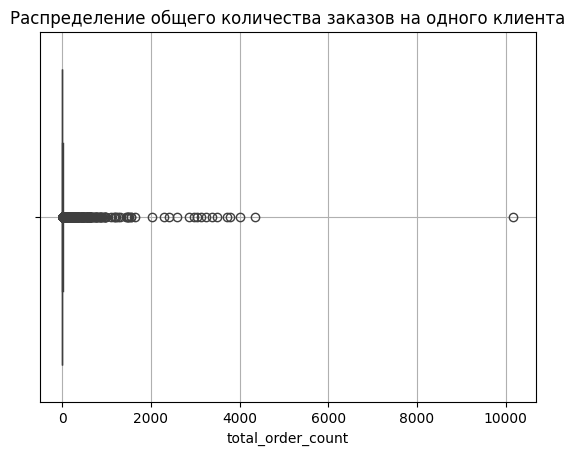

In [134]:
# общее число заказов
sns.boxplot(data=df_users_profile, x='total_order_count')
discribe_analysis(df_users_profile['total_order_count'], qnt=0.99)
plt.title('Распределение общего количества заказов на одного клиента')
plt.grid()

- данные по количеству заказов имеют существенные выбросы. Для анализа можно отфильтровать выбросы

99.0 % значений менее 5.0
Минимальное значение:  1.0
Медиана:  2.75
Максимальное значение:  11.0
Размах:  10.0


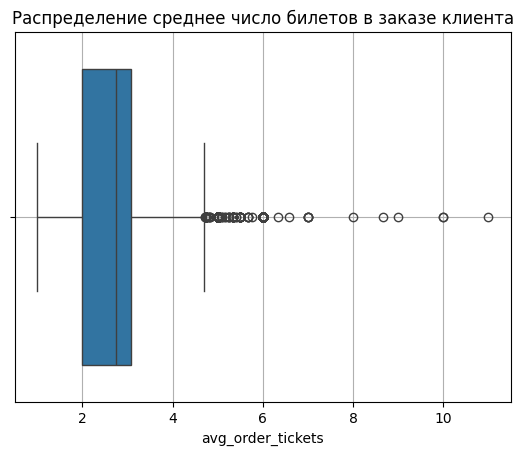

In [135]:
# среднее число билетов в заказе
sns.boxplot(data=df_users_profile, x='avg_order_tickets')
discribe_analysis(df_users_profile['avg_order_tickets'], qnt=0.99)
plt.title('Распределение среднее число билетов в заказе клиента')
plt.grid()

- данные по среднему числу билетов в заказе имеют выбросы

In [136]:
df_users_profile['avg_time_between_orders_days'] = df_users_profile['avg_time_between_orders'].dt.days

In [137]:
# среднее количество дней между покупками 
print('Доля пропусков: ', df_users_profile['avg_time_between_orders_days'].isna().sum() / len(df_users_profile))

Доля пропусков:  0.3829563146808316


- 38% пользователей заказали лишь один раз

95.0 % значений менее 61.0
Минимальное значение:  0.0
Медиана:  8.0
Максимальное значение:  148.0
Размах:  148.0


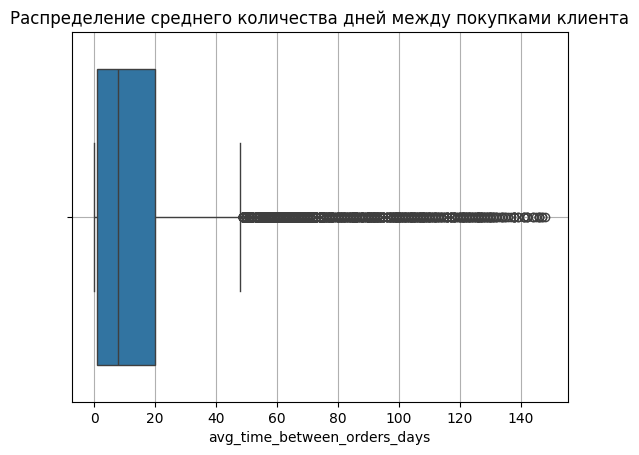

In [138]:
# среднее количество дней между покупками 
sns.boxplot(data=df_users_profile, x='avg_time_between_orders_days')
discribe_analysis(df_users_profile['avg_time_between_orders_days'], qnt=0.95)
plt.title('Распределение среднего количества дней между покупками клиента')
plt.grid()

- данные по количеству дней между покупками имеют выбросы.

### Промежуточный итог:

- общее число пользователей:  21838. Данных по объему достаточно для анализа
- общее число заказов содержит выбросы: Медиана:  2.0, 99.0 % значений менее 152. Присутствует аномальное значение: 10168.
- данные по среднему числу билетов в заказе имеют выбросы. Медиана:  2.75, 99.0 % значений менее 5. Максимальное значение:  11.
- 38% пользователей заказали лишь один раз
- данные по количеству дней между покупками имеют выбросы. Медиана:  8, 95.0 % значений менее 61. Максимальное значение:  148

### Работа с выбросами

In [139]:
# фиксация размера датасета до фильтрации
prev_size = len(df_users_profile)

Данные по **количеству заказов** стоит отфильтровать по 99 перцентилю. 
- Возможно, выбросы связаны с наличием корпоративных клиентов (организации, юридические лица). Они делают массовые заказы на группу людей. Анализ таких клиентов в рамках настоящего исследования нас не интересует, так что можно их отфильтровать.

In [140]:
df_users_profile = df_users_profile.drop(df_users_profile[df_users_profile['total_order_count'] > df_users_profile['total_order_count'].quantile(0.99)].index)

**Данные по среднему числу билетов** в заказе имеют выбросы. Экстремальных значений довольно мало. Можно отфильтровать по 99 перцентилю без существенных искажений

In [141]:
df_users_profile = df_users_profile.drop(df_users_profile[df_users_profile['avg_order_tickets'] > df_users_profile['avg_order_tickets'].quantile(0.99)].index)

**Данные по количеству дней между покупками** имеют выбросы. Экстремальные значения распределены по дианазону 61-148 достаточно равномерно. Можно пока оставить эти данные и потом учесть при анализе.

In [142]:
# анализ потерь
print('Потери при фильтрации: ', (prev_size - len(df_users_profile)) / prev_size * 100, '%') 

Потери при фильтрации:  1.877461305980401 %


In [143]:
# статистические данные по обновленному датасету
df_users_profile.describe()

,first_order_id,first_order_ts,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,avg_time_between_orders_days
count,2.142800e+04,21428,21428,21428.000000,21428.000000,21428.000000,13196,13196.000000
mean,4.343117e+06,2024-08-11 02:07:20.435271,2024-09-18 16:29:27.850896,6.539248,543.009284,2.714772,16 days 04:44:45.738448,15.798121
min,1.161000e+03,2024-06-01 00:01:58,2024-06-01 01:29:40,1.000000,0.000000,1.000000,0 days 00:00:01,0.000000
25%,2.230638e+06,2024-06-26 12:03:36.500000,2024-08-24 21:02:23,1.000000,210.537083,2.000000,1 days 10:43:10.522060,1.000000
50%,4.320290e+06,2024-08-09 19:08:57.500000,2024-10-02 23:37:53.500000,2.000000,463.277500,2.750000,8 days 11:57:27.994485,8.000000
75%,6.519788e+06,2024-09-23 11:19:15.250000,2024-10-22 14:02:43.500000,5.000000,765.709976,3.000000,20 days 21:29:59.083333,20.000000
max,8.652818e+06,2024-10-31 23:55:27,2024-10-31 23:59:54,152.000000,2628.421739,5.000000,148 days 05:27:58,148.000000
std,2.496602e+06,NaN,NaN,14.367341,430.304994,0.864846,22 days 09:43:14.413323,22.333309


### Промежуточный итог:

- в ходе анализа распределения данных были выявлены выбросы в данных среди: количества заказов, среднего числа билетов, количества дней между покупками
- принято решение отфильтровать данные по 99 перцинтилю среди: количества заказов, среднего числа билетов
- выбросы по количеству дней между покупками необходимо учитвывать при дальнейшем анализе
- Потери при фильтрации:  1.88 %

---

### 4. Исследовательский анализ данных

Исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. 



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследование признаков, описывающих первый заказ пользователя.

---

**4.1.1.** Изучение распределения пользователей по признакам.

---


In [144]:
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five,avg_time_between_orders_days
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000,NaT,False,False,NaN
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38,True,False,74.0
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36,True,False,50.0
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000,NaT,False,False,NaN
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52,True,False,15.0


In [145]:
def plot_segment_share_dist(column_to_plot: pd.Series, title: str = ''):

    abs_counts = column_to_plot.value_counts()
    rel_counts = column_to_plot.value_counts(normalize=True)
    dist = pd.concat([abs_counts, rel_counts], axis=1)
    dist.columns = ['absolute', 'relative']

    print('Распределение по абсолютной и относительной величине:')
    print(dist)

    share = rel_counts.sort_values()

    ax = share.plot(
        kind='barh', figsize=(10, 6), color='cornflowerblue'
    )

    ax.set_ylabel('Категория')          
    ax.set_xlabel('Проценты')   
    ax.set_title(title)

    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

    for i, v in enumerate(share.values):
        ax.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

Распределение по абсолютной и относительной величине:
                             absolute  relative
first_order_event_type_main                    
концерты                         9518  0.444185
другое                           5320  0.248273
театр                            4210  0.196472
стендап                          1096  0.051148
спорт                             779  0.036354
выставки                          410  0.019134
ёлки                               95  0.004433


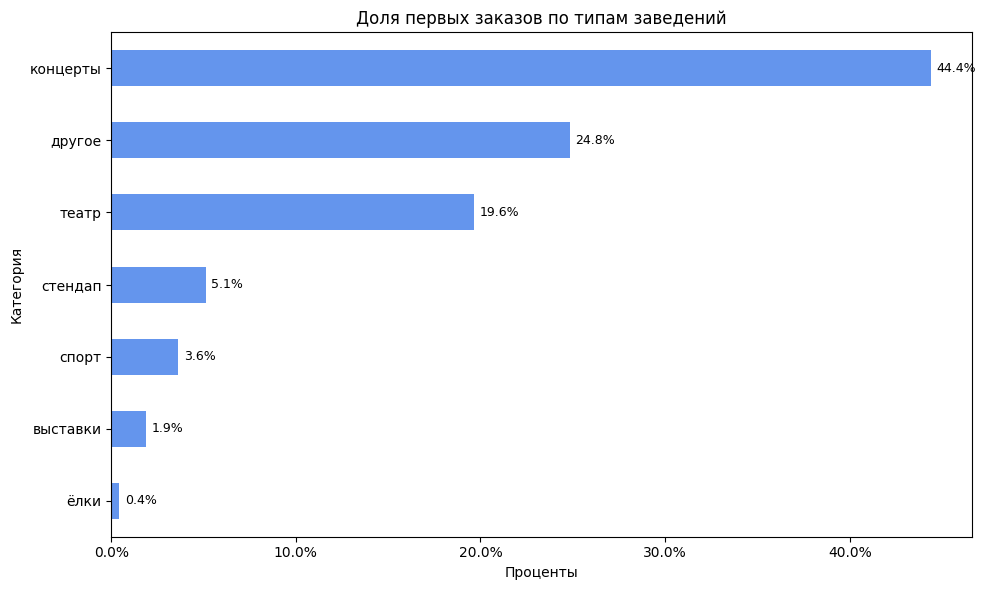

In [146]:
# группировка по типу первого мероприятия
plot_segment_share_dist(
    df_users_profile['first_order_event_type_main'], 
    title='Доля первых заказов по типам заведений'
)

- по типу первого мероприятия есть явный лидер: доля концертов 44.4%
- выделяется категория "другое" с 24.8% - это отсутствие информации о меропрятии
- существенная доля у театров: 19.6%
- по остальным категориям гораздо меньше клиентов: менее 6 процентов для каждой категории (стендапа, спорта, выставок, елок)

Распределение по абсолютной и относительной величине:
                    absolute  relative
first_order_device                    
mobile                 17751  0.828402
desktop                 3677  0.171598


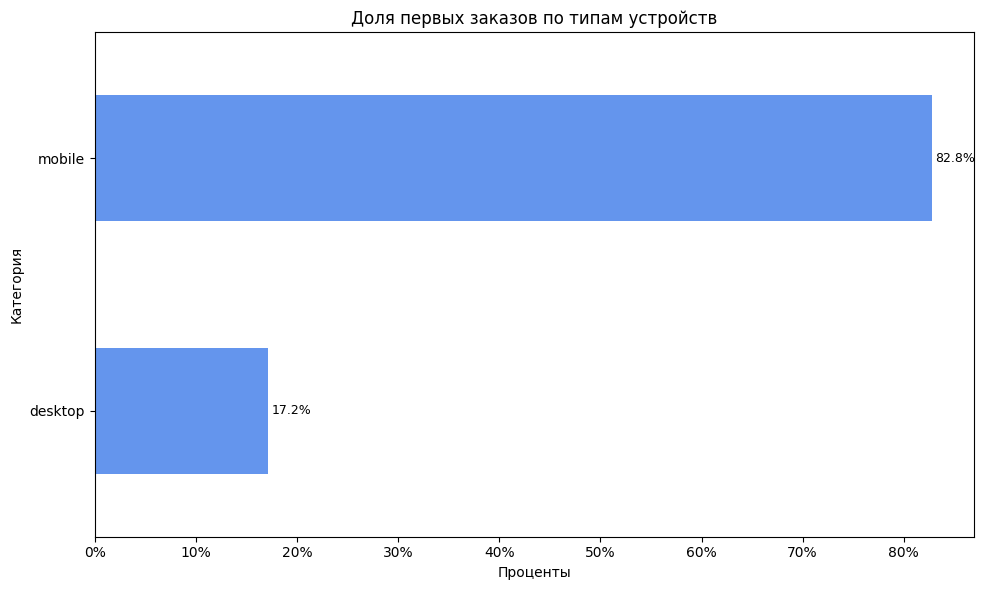

In [147]:
# группировка по типу утройства первого заказа
plot_segment_share_dist(
    df_users_profile['first_order_device'],
    title='Доля первых заказов по типам устройств'
)

- с мобильных телефонов гораздо чаще делают первые заказы: 82.8% 


In [150]:
# группировка по региону проведения первого мероприятия
ordered_regions = df_users_profile['first_order_region_name'].value_counts(normalize=True).reset_index()

# фильтруем регионы, доля которых более threshold
threshold = 0.005
first_order_region_name_significant = ordered_regions[ordered_regions['proportion'] > threshold]

print(
    'Суммарная доля малозначимых регионов: ', 
    ordered_regions[ordered_regions['proportion'] <= threshold]['proportion'].sum()
)


Суммарная доля малозначимых регионов:  0.08680231472839278


In [151]:
first_order_region_name_significant

,first_order_region_name,proportion
0,каменевский_регион,0.328169
1,североярская_область,0.173418
2,широковская_область,0.056422
3,озернинский_край,0.031314
4,малиновоярский_округ,0.024361
5,шанырский_регион,0.023427
6,травяная_область,0.022587
7,светополянский_округ,0.021234
8,речиновская_область,0.020394
9,яблоневская_область,0.018947


Распределение по абсолютной и относительной величине:
                           absolute  relative
first_order_region_name                      
каменевский_регион             7032  0.359362
североярская_область           3716  0.189902
широковская_область            1209  0.061785
озернинский_край                671  0.034291
малиновоярский_округ            522  0.026676
шанырский_регион                502  0.025654
травяная_область                484  0.024734
светополянский_округ            455  0.023252
речиновская_область             437  0.022332
яблоневская_область             406  0.020748
верхоречная_область             373  0.019062
медовская_область               369  0.018857
лугоградская_область            357  0.018244
серебринская_область            327  0.016711
тепляковская_область            321  0.016404
солнечнореченская_область       292  0.014922
солнечноземская_область         279  0.014258
горицветская_область            245  0.012520
глиногорская_область      

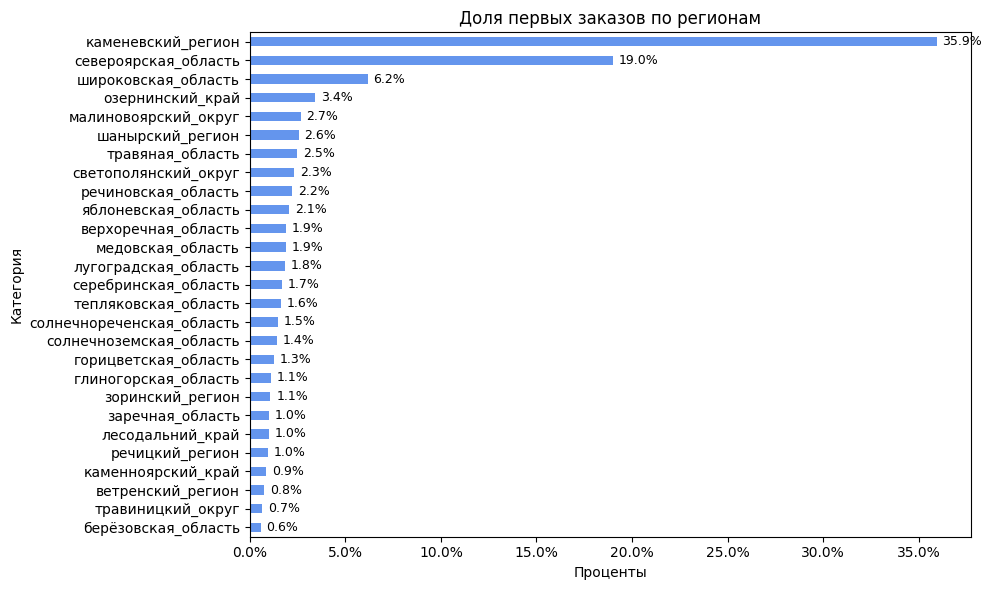

In [153]:
first_region_name = df_users_profile[df_users_profile['first_order_region_name'].isin(first_order_region_name_significant['first_order_region_name'].unique().tolist())]

plot_segment_share_dist(
    first_region_name['first_order_region_name'],
    title='Доля первых заказов по регионам'
)

- для отображения наиболее значимых регионов применена фильтрация: регионы с долей менее 0.5% составляют 8.6% от общего количества 
- лидеры среди значимх районов (с долей более 0.5% в общем датасете): 
    - каменевский_регион 36%
    - североярская_область 19%
    - широковская_область  6%

Распределение по абсолютной и относительной величине:
                          absolute  relative
first_order_service_name                    
билеты_без_проблем            5096  0.237820
мой_билет                     2948  0.137577
лови_билет                    2790  0.130203
билеты_в_руки                 2536  0.118350
облачко                       2166  0.101083
весь_в_билетах                1275  0.059502
лучшие_билеты                 1171  0.054648
прачечная                      579  0.027021
край_билетов                   452  0.021094
дом_культуры                   353  0.016474
яблоко                         316  0.014747
тебе_билет                     304  0.014187
городской_дом_культуры         213  0.009940
мир_касс                       210  0.009800
за_билетом                     197  0.009194
быстробилет                    160  0.007467
show_ticket                    157  0.007327
выступленияру                   94  0.004387
восьмёрка                       85  0.003967
б

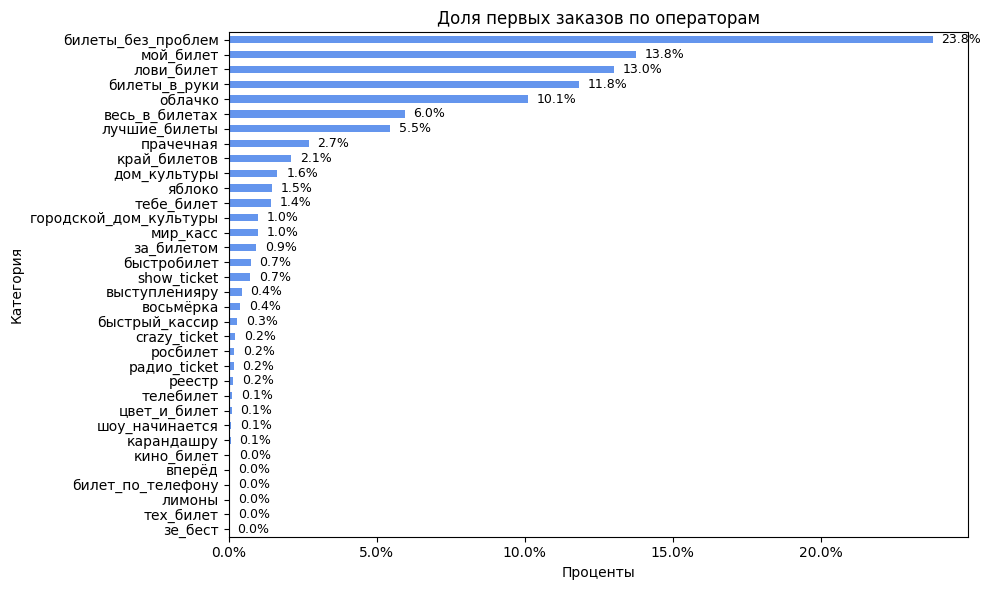

In [154]:
# по билетному оператору
plot_segment_share_dist(
    df_users_profile['first_order_service_name'],
    title='Доля первых заказов по операторам'
)

- лидеры по билетному оператору:
    - билеты_без_проблем 23%
    - мой_билет 13%
    - лови_билет 13%
    - билеты_в_руки 11%
    - облачко 10%
- остальные не более 6% 

### Промежуточный итог:

пользователи распределены по сегментам **неравномерно**. Присутствуют явные точки входа: 
- по типу первого мероприятия есть явный лидер: доля **концертов** 44.4%
- по устройствам: 
    - **мобильные телефоны** 82.8% 
- по районам: 
    - **каменевский_регион** 36%, 
    - североярская_область 19%, 
    - широковская_область  6%
- по билетному оператору:
    - **билеты_без_проблем** 23%
    - мой_билет 13%
    - лови_билет 13%
    - билеты_в_руки 11%
    - облачко 10%

---

**4.1.2.** Анализ возврата пользователей:

---


In [155]:
def show_category_parts(
    df_to_analyse: pd.DataFrame, 
    colname_groupby: str, 
    part_category: str, 
    title: str = '', 
    df_init: pd.DataFrame = None
):
    df_unstack = df_to_analyse.groupby(colname_groupby)[part_category].value_counts(normalize=True).unstack(fill_value=0)

    if True in df_unstack.columns:
        sort_col = True
    elif 1 in df_unstack.columns:
        sort_col = 1
    else:
        sort_col = df_unstack.columns[0]

    df_unstack = df_unstack.sort_values(by=sort_col, ascending=False)
    print(df_unstack)

    if df_init is not None:
        df_init_unstack = df_init.groupby(colname_groupby)[part_category].value_counts(normalize=True).unstack(fill_value=0)
        mean_share = df_init_unstack[sort_col].mean()
    else:
        mean_share = df_unstack[sort_col].mean()
    print(f'Средняя доля по "{sort_col}": {mean_share:.1%}')


    ax = df_unstack.plot(kind='bar')
    ax.axhline(mean_share, color='tomato', linestyle='--', linewidth=1.5, label='Среднее по выборке')


    plt.title(title)
    plt.ylabel('Доля') 
    plt.xlabel('Категория') 
    plt.xticks(rotation=45)  
    plt.legend()  

    # Отображаем график
    plt.show()

is_two                          False     True 
first_order_event_type_main                    
выставки                     0.358537  0.641463
театр                        0.362470  0.637530
концерты                     0.380857  0.619143
стендап                      0.387774  0.612226
другое                       0.399248  0.600752
спорт                        0.440308  0.559692
ёлки                         0.442105  0.557895
Средняя доля по "True": 60.4%


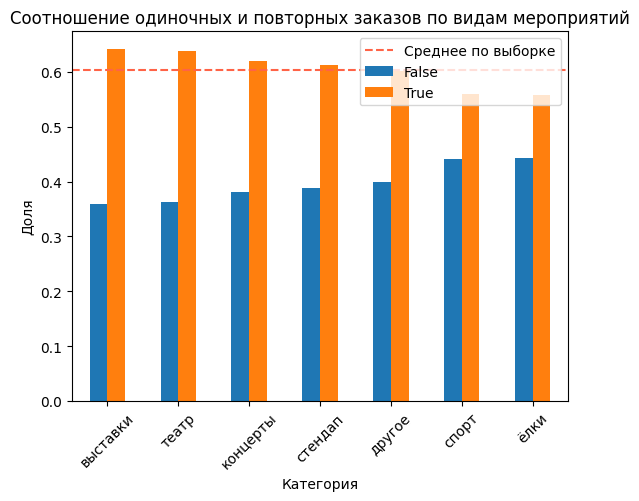

In [156]:
show_category_parts(
    df_users_profile, 
    colname_groupby='first_order_event_type_main', 
    part_category='is_two',
    title='Соотношение одиночных и повторных заказов по видам мероприятий'
)

- доля пользователей с 2мя и более заказами выше среднего для: выставок, театров, концертов, стендапов (от 61% до 64%)


is_two                 False     True 
first_order_device                    
desktop             0.358716  0.641284
mobile              0.389443  0.610557
Средняя доля по "True": 62.6%


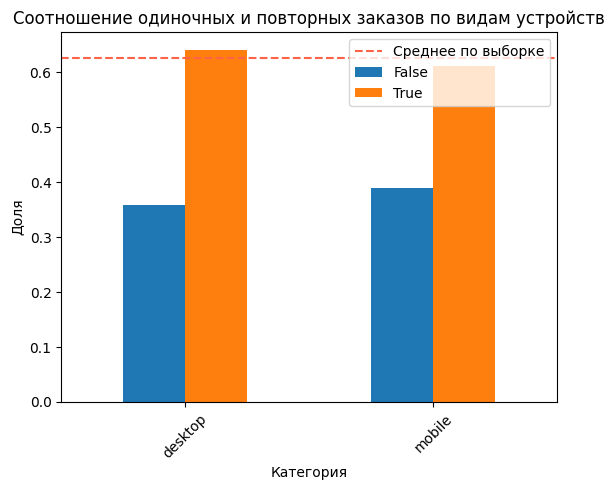

In [157]:
show_category_parts(
    df_users_profile, 
    colname_groupby='first_order_device', 
    part_category='is_two',
    title='Соотношение одиночных и повторных заказов по видам устройств'
)

- доля пользователей с 2ми и более заказами среди устройств выше для компьютеров 64%, но не существенно. Для мобильных составляет 61%

is_two                      False     True 
first_order_region_name                    
шанырский_регион         0.326693  0.673307
светополянский_округ     0.342857  0.657143
широковская_область      0.350703  0.649297
североярская_область     0.358450  0.641550
речиновская_область      0.366133  0.633867
каменевский_регион       0.373720  0.626280
травяная_область         0.382231  0.617769
яблоневская_область      0.399015  0.600985
малиновоярский_округ     0.442529  0.557471
озернинский_край         0.444113  0.555887
Средняя доля по "True": 55.9%


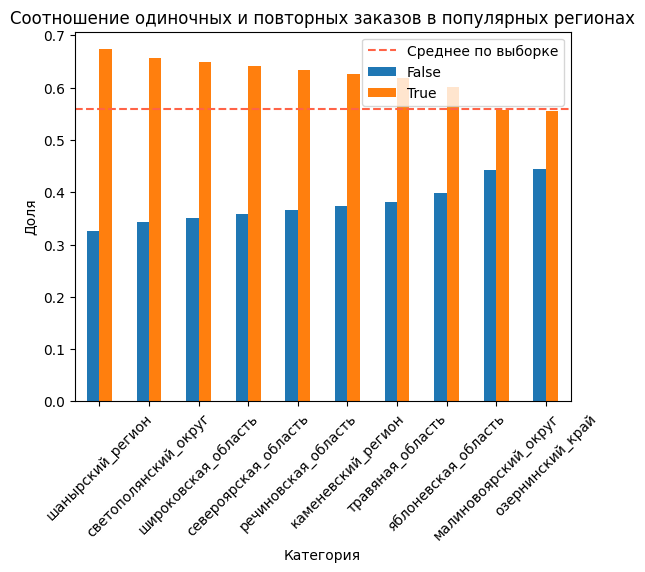

In [160]:
ordered_regions = df_users_profile['first_order_region_name'].value_counts(normalize=True).reset_index().sort_values(by='proportion', ascending=False)
top_regions = ordered_regions.head(10)['first_order_region_name'].tolist()
first_region_name_top_regions = df_users_profile[df_users_profile['first_order_region_name'].isin(top_regions)]

show_category_parts(
    first_region_name_top_regions, 
    colname_groupby='first_order_region_name', 
    part_category='is_two', 
    df_init=df_users_profile,
    title='Соотношение одиночных и повторных заказов в популярных регионах'
)

- cреди регионов выделяются (доля более 60%):
    - шанырский_регион         67%
    - светополянский_округ     65%
    - широковская_область      64%
    - североярская_область     64%
    - речиновская_область      63%
    - каменевский_регион       62%
    - травяная_область         61%
    - яблоневская_область      60%

- Средняя доля по выборке: 55.9%

is_two                       False     True 
first_order_service_name                    
дом_культуры              0.348442  0.651558
край_билетов              0.349558  0.650442
весь_в_билетах            0.369412  0.630588
билеты_в_руки             0.370662  0.629338
прачечная                 0.371330  0.628670
лучшие_билеты             0.382579  0.617421
облачко                   0.386427  0.613573
лови_билет                0.387455  0.612545
мой_билет                 0.390434  0.609566
билеты_без_проблем        0.392268  0.607732
Средняя доля по "True": 61.7%


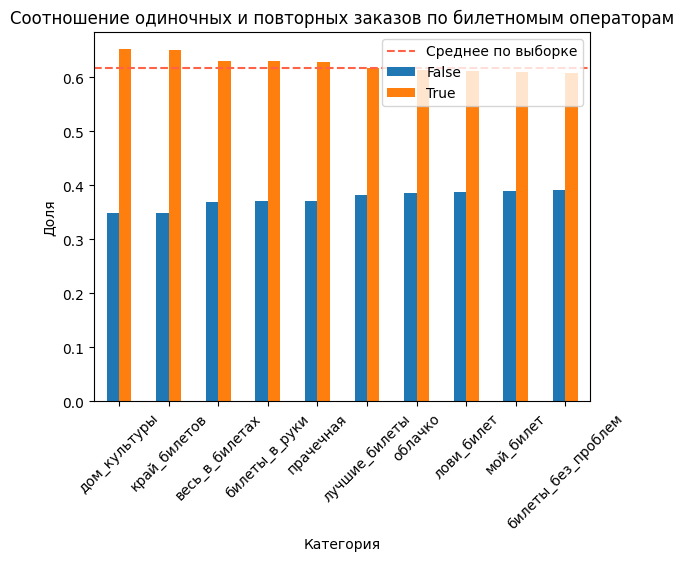

In [161]:
# по билетному оператору
ordered_service_name = df_users_profile['first_order_service_name'].value_counts(normalize=True).reset_index().sort_values(by='proportion', ascending=False)
top_service_name = ordered_service_name.head(10)['first_order_service_name'].tolist()
first_order_service_name_top = df_users_profile[df_users_profile['first_order_service_name'].isin(top_service_name)]

show_category_parts(
    first_order_service_name_top, 
    colname_groupby='first_order_service_name', 
    part_category='is_two', 
    df_init=df_users_profile,
    title='Соотношение одиночных и повторных заказов по билетномым операторам'
)


- лидеры среди билетных операторов:
    - дом_культуры  65%
    - край_билетов  65%
    - весь_в_билетах 63%
    - билеты_в_руки  63%
    - прачечная 63%
- Средняя доля по выборке: 61.7%

### Промежуточные выводы:

Сегменты пользователей, которые чаще возвращаются на Яндекс Афишу:
- пользователи, посетившие в первый раз: выставоку, театр, концерт, стендап (доля повторных заказов от 61% до 64%, что выше среднего по выборке)
- пользователи, совершившие покупку с компьютеров 64% (выше среднего по выборке), возвращаются чаще, чем с мобильных 61%
- пользователи, по посетившие в первый раз из регионов (указан процент пользователей с повторной покупкой, выше средней доле по выборке: 55.9%):
    - шанырский_регион         67%
    - светополянский_округ     65%
    - широковская_область      64%
    - североярская_область     64%
    - речиновская_область      63%
    - каменевский_регион       62%
    - травяная_область         61%
    - яблоневская_область      60%

- пользователи, воспользовавшиеся билетными операторами (указан процент пользователей с повторной покупкой, выше средней доле по выборке: 61.7%):
    - дом_культуры  65%
    - край_билетов  65%
    - весь_в_билетах 63%
    - билеты_в_руки  63%
    - прачечная 63%


---

**4.1.3.** Проверка продуктовых гипотез:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

- исходя из анализа выше, **Гипотеза 1 неверна**: доля повторных заказов при первом посещении концерта 64% > спортивного меропрятия 56%. То есть пользователи, которые совершили первый заказ на концерт совершили больше повторных покупок впоследствии, нежели те, кто посетил первым спортивное мероприятие. Тип мероприятия влияет на вероятность возврата, но не так, как это описано в проверяемой гипотезе.

In [162]:
# проверка 2ой гипотезы:
# упорядоченные по популярности мероприятий регионы
ordered_regions = (
    df_users_profile
        .groupby('first_order_region_name')
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
)
ordered_regions['region_rank'] = ordered_regions.index + 1
ordered_regions

,first_order_region_name,count,region_rank
0,каменевский_регион,7032,1
1,североярская_область,3716,2
2,широковская_область,1209,3
3,озернинский_край,671,4
4,малиновоярский_округ,522,5
...,...,...,...
76,залесский_край,2,77
77,тихогорская_область,2,78
78,верхозёрский_край,1,79
79,сосноводолинская_область,1,80


In [163]:
# регионы с долями по повторным покупкам
top_regions_is_two = (
    df_users_profile
        .groupby('first_order_region_name')['is_two']
        .mean()                         # True=1, False=0 → сразу получаем долю
        .reset_index(name='share_is_two')
)
top_regions_is_two

,first_order_region_name,share_is_two
0,белоярская_область,0.631579
1,берестовский_округ,0.636364
2,берёзовская_область,0.657658
3,боровлянский_край,0.515464
4,верховинская_область,0.666667
...,...,...
76,шанырский_регион,0.673307
77,широковская_область,0.649297
78,яблоневская_область,0.600985
79,ягодиновская_область,0.666667


In [164]:
ordered_regions['first_order_region_name'] = ordered_regions['first_order_region_name'].astype('string')
top_regions_is_two['first_order_region_name'] = top_regions_is_two['first_order_region_name'].astype('string')

df_to_analyse = ordered_regions.merge(
    top_regions_is_two,
    on='first_order_region_name',
    how='left'
)

df_to_analyse[['region_rank', 'share_is_two']].corr(method='spearman')

,region_rank,share_is_two
region_rank,1.000000,-0.316084
share_is_two,-0.316084,1.000000


- выше представлена матрица корреляции признаков: популярность региона и вероятность повторной покупки

- **Гипотеза 2 неверна**: общая посещаемость мероприятий имеет мало связана с долей повторных визитов в регионах

#### Промежуточный вывод:

- тип мероприятия мало влияет на вероятность возврата на Яндекс Афишу: 
    разница по доле повторных покупок достигает 8%
- общая посещаемость мероприятий имеет мало связана с долей повторных визитов в регионах (корреляция -0.31)

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучение количественных характеристик заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**4.2.1.** Оценка связи между средней выручкой сервиса с заказа и повторными заказами.

---


In [165]:
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five,avg_time_between_orders_days
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000,NaT,False,False,NaN
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38,True,False,74.0
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36,True,False,50.0
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000,NaT,False,False,NaN
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52,True,False,15.0


In [166]:
# средняя выручка с билета
df_users_profile['avg_revenue_rub'] = df_users_profile['avg_order_revenue'] / df_users_profile['avg_order_tickets']

Text(0.5, 1.0, 'Плотность распределений средней выручки с заказа \n по клиентам с одиночными и повторными заказами')

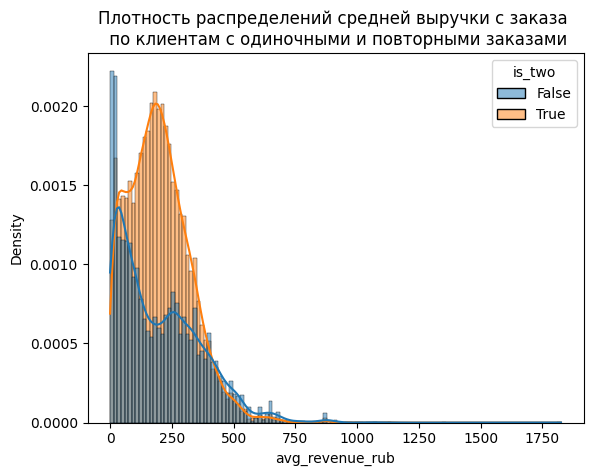

In [167]:
sns.histplot(data=df_users_profile, x='avg_revenue_rub', hue='is_two', kde=True, stat='density')
plt.title(f'Плотность распределений средней выручки с заказа \n по клиентам с одиночными и повторными заказами')

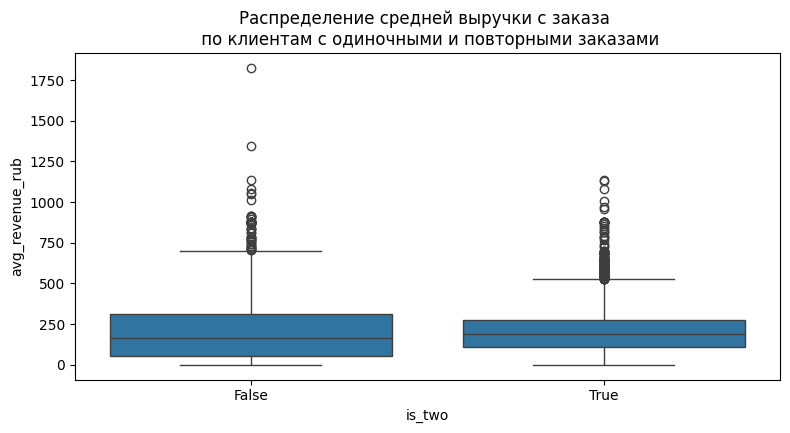

In [168]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df_users_profile, x='is_two', y='avg_revenue_rub', ax=ax)
ax.set_xlabel('is_two')
ax.set_ylabel('avg_revenue_rub')
plt.tight_layout()
plt.title(f'Распределение средней выручки с заказа \n по клиентам с одиночными и повторными заказами')
plt.show()

In [169]:
# диапазоны концентрации: межквартильный размах (Q1–Q3) по группам is_two
q = df_users_profile.groupby('is_two')['avg_revenue_rub'].quantile([0.25, 0.5, 0.75]).unstack()
q.columns = ['Q1', 'median', 'Q3']
print('Значения выручки концентрируется в диапазонах')
print(q)
print('-'* 100)
q_median_rel_diff = (q['median'].max() - q['median'].min()) / q['median'].max() * 100
print('Относительное изменение медианного значения выручки: ', q_median_rel_diff)
print('Q1-Q3 квантильный размах: ', abs((q['Q3'] - q['Q1']).diff() / (q['Q3'] - q['Q1']).max()) * 100 )

Значения выручки концентрируется в диапазонах
                Q1      median          Q3
is_two                                    
False    56.760000  165.715000  313.355417
True    106.902846  189.456994  275.671500
----------------------------------------------------------------------------------------------------
Относительное изменение медианного значения выручки:  12.531600712588281
Q1-Q3 квантильный размах:  is_two
False          NaN
True     34.227721
dtype: float64


### Промежуточный вывод:
- между группами средней выручки с билета (`avg_revenue_rub`) есть отличия: 
    - медианный чек для пользователей, сделавших более одного заказа выше на 12.5%
    - Q1-Q3 квантильный размах для пользователей, сделавших более одного заказа меньше на 34%. То есть распределение более кучное и симметричное для клиентов с большим количеством заказов
    
Следовательно, для роста количества повторных заказов необходимо повышать средний чек одного заказа. Допустим, можно запустить акцию с купонами на скидку при заказах от более высоких сумм. 

---

**4.2.2.** Сравнение распределений по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.
---


In [170]:
# совершившие 2-4 заказа
df_users_profile_2_4 = df_users_profile[(df_users_profile['is_two'] == True) & (df_users_profile['is_five'] == False)]
df_users_profile_2_4.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five,avg_time_between_orders_days,avg_revenue_rub
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38,True,False,74.0,258.003333
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36,True,False,50.0,287.705000
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52,True,False,15.0,40.873333
6,00147c9209d45d3,mobile,4361340,2024-06-25 23:26:58,каменевский_регион,облачко,концерты,2024-06-25 23:28:52,2,352.945000,1.500000,0 days 00:01:54,True,False,0.0,235.296667
9,001e7037d013f0f,mobile,1673330,2024-07-04 08:06:44,златопольский_округ,мой_билет,другое,2024-09-29 22:58:14,3,326.623333,1.333333,43 days 19:25:45,True,False,43.0,244.967500


In [171]:
# совершившие >=5 заказов
df_users_profile_5 = df_users_profile[(df_users_profile['is_five'] == True)]
df_users_profile_5.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five,avg_time_between_orders_days,avg_revenue_rub
5,000cf0659a9f40f,mobile,6818017,2024-06-20 10:35:26,широковская_область,лови_билет,концерты,2024-06-21 04:36:17,13,1175.808462,3.307692,0 days 01:30:04.250000,True,True,0.0,355.476977
13,002b75ca606ba46,desktop,4938817,2024-07-08 13:02:39,каменевский_регион,быстробилет,концерты,2024-10-16 18:57:09,6,443.580000,3.000000,20 days 01:10:54,True,True,20.0,147.860000
15,002ec276eee9b0b,mobile,7463760,2024-07-10 00:43:41,широковская_область,мой_билет,концерты,2024-10-31 13:17:33,22,811.942727,2.863636,5 days 09:44:28.190476,True,True,5.0,283.535556
16,0033403583a55ed,mobile,4130529,2024-06-19 10:53:29,каменевский_регион,билеты_без_проблем,другое,2024-09-17 16:52:06,6,135.692294,1.666667,18 days 01:11:43.400000,True,True,18.0,81.415376
18,00345f897f95a34,mobile,5380110,2024-06-02 08:00:46,лесодальний_край,тебе_билет,концерты,2024-10-23 22:01:19,8,1338.258750,2.875000,20 days 12:17:13.285714,True,True,20.0,465.481304


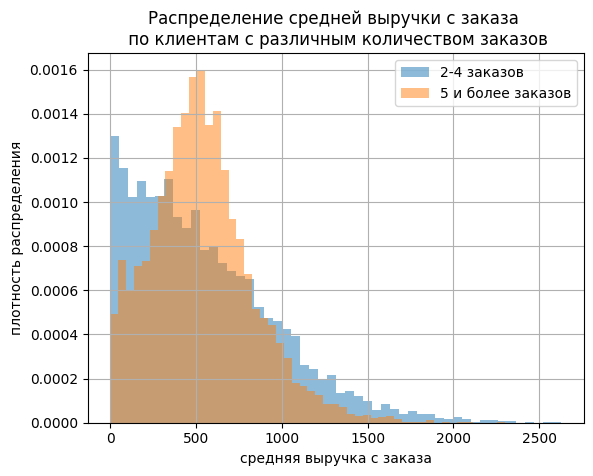

In [172]:
bins = 50
alpha=0.5
df_users_profile_2_4['avg_order_revenue'].hist(bins=bins, alpha=alpha, density=True, label='2-4 заказов')
df_users_profile_5['avg_order_revenue'].hist(bins=bins, alpha=alpha, density=True, label='5 и более заказов')
plt.xlabel('средняя выручка с заказа')
plt.ylabel('плотность распределения')
plt.title(f'Распределение средней выручки с заказа \n по клиентам с различным количеством заказов')
plt.legend()

In [173]:
df_users_profile_2_4['avg_order_revenue'].describe()

count    7090.000000
mean      550.009207
std       416.790512
min         0.000000
25%       218.755000
50%       471.040000
75%       797.547500
max      2628.421739
Name: avg_order_revenue, dtype: float64

In [174]:
df_users_profile_5['avg_order_revenue'].describe()

count    6106.000000
mean      535.857438
std       297.314368
min         0.000000
25%       331.683411
50%       513.088937
75%       700.601250
max      2299.869022
Name: avg_order_revenue, dtype: float64

In [175]:
median_2_4 = df_users_profile_2_4['avg_order_revenue'].median()
median_5 = df_users_profile_5['avg_order_revenue'].median()
q_median_rel_diff = (median_5 - median_2_4) / max(median_5, median_2_4) * 100
print('Относитальное изменение медианного значения выручки: ', q_median_rel_diff)

Относитальное изменение медианного значения выручки:  8.195253186490689


### Промежуточные выводы:
- есть различия по величине выручки с заказа между категориями (2-4 заказов) и (5 и более заказов): 
    - Относитальное изменение медианного значения выручки 8.19% в пользу клиентов с 5 и более заказами
    
***По результатам анализа сегментов можно сделать вывод:***
- чем больше клиенты делают заказов, тем выше средняя выручка с каждого их заказа


---

**4.2.3.** Анализ влияния среднего количества билетов в заказе на вероятность повторной покупки.

---

In [176]:
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five,avg_time_between_orders_days,avg_revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000,NaT,False,False,NaN,380.485000
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38,True,False,74.0,258.003333
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36,True,False,50.0,287.705000
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000,NaT,False,False,NaN,229.457500
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52,True,False,15.0,40.873333


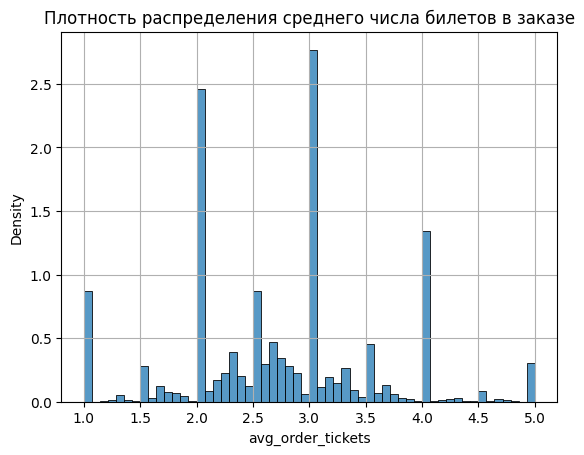

In [177]:
sns.histplot(data=df_users_profile, x='avg_order_tickets', stat='density')
plt.title('Плотность распределения среднего числа билетов в заказе')
plt.grid()

- распределение среднего количества билетов в заказе имеет явные пики в значениях: 1, 2, 2.5, 3, 4, 5

In [178]:
# сегментация по avg_order_tickets и расчет доли повторных заказов
bins = [1, 2, 3, 5, float('inf')]
labels = ['1–2', '2–3', '3–5', '5+']

segmented = df_users_profile.copy()
segmented['tickets_segment'] = pd.cut(segmented['avg_order_tickets'], bins=bins, labels=labels, right=True, include_lowest=True)
segmented
segment_stats = (
    segmented.groupby('tickets_segment')
    .agg(total_users=('user_id', 'nunique'),
         repeat_users=('is_two', 'sum'),
         repeat_share=('is_two', 'mean'))
    .reset_index()
)
segment_stats['total_users_share'] = segment_stats['total_users'] / segment_stats['total_users'].sum()

print(segment_stats)



  tickets_segment  total_users  repeat_users  repeat_share  total_users_share
0             1–2         6150          2467      0.401138           0.287008
1             2–3         9922          7368      0.742592           0.463039
2             3–5         5356          3361      0.627521           0.249953


### Промежуточный вывод:

Сегментация:
- большая часть пользователей сконцентрирована в сегменте 2–3 среднего билета в заказе: 46%
- сегменты 1–2 и 3–5 близки до доле: 29% и 25%
- сегмент 5 и более в данных не встречается

Доля повторных покупок в сегментах:
- в сегменте 2–3 доля высокая: 74%
- в сегменте 1-2 доля низкая: 40%

Следовательно, для увеличения доли повторных заказов необходимо повлиять на сегмент 1-2 заказа в сторону повышения количество купленных билетов в одном заказе у клиента. 
Возможно, запустить акицию на покупку нескольких билетов в отдном заказе.
Надо сконцентрироваться на группе 1-2 билета и стимулировать их брать больше в один заказ.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучение временных параметров, связанных с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**4.3.1.** Анализ: как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

---


In [179]:
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five,avg_time_between_orders_days,avg_revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000,NaT,False,False,NaN,380.485000
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38,True,False,74.0,258.003333
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36,True,False,50.0,287.705000
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000,NaT,False,False,NaN,229.457500
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52,True,False,15.0,40.873333


In [180]:
# сегментация по дням недели первого заказа и доля повторных заказов
segmented = df_users_profile.copy()
segmented['first_order_ts'] = pd.to_datetime(segmented['first_order_ts'], errors='coerce')
segmented['weekday'] = segmented['first_order_ts'].dt.day_name()

weekday_stats = (
    segmented.groupby('weekday')
    .agg(total_users=('user_id', 'nunique'),
         repeat_users=('is_two', 'sum'),
         repeat_share=('is_two', 'mean'))
    .reset_index()
)

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_stats['weekday'] = pd.Categorical(weekday_stats['weekday'], categories=weekday_order, ordered=True)
weekday_stats = weekday_stats.sort_values('weekday')

print(weekday_stats)

     weekday  total_users  repeat_users  repeat_share
1     Monday         2894          1827      0.631306
5    Tuesday         3144          1952      0.620865
6  Wednesday         3031          1896      0.625536
4   Thursday         3086          1841      0.596565
0     Friday         3230          1940      0.600619
2   Saturday         3295          2077      0.630349
3     Sunday         2748          1663      0.605167


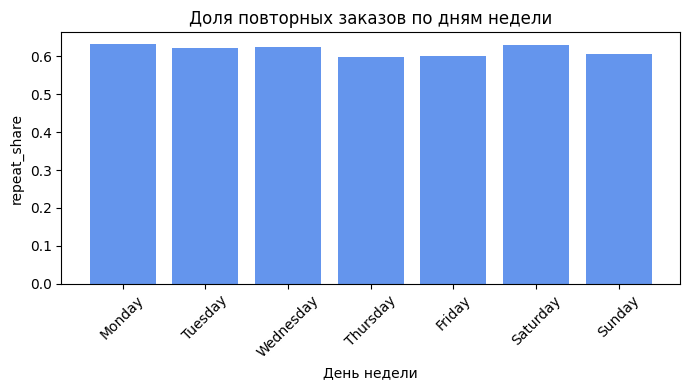

In [181]:
# bar chart: дни недели по x, repeat_share по y
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weekday_stats['weekday'].astype(str), weekday_stats['repeat_share'], color='cornflowerblue')
ax.set_title('Доля повторных заказов по дням недели')
ax.set_xlabel('День недели')
ax.set_ylabel('repeat_share')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [182]:
weekday_stats['repeat_share'].describe()

count    7.000000
mean     0.615773
std      0.014640
min      0.596565
25%      0.602893
50%      0.620865
75%      0.627943
max      0.631306
Name: repeat_share, dtype: float64

In [183]:
(weekday_stats['repeat_share'].max() - weekday_stats['repeat_share'].min()) / weekday_stats['repeat_share'].max() * 100

np.float64(5.50303806834971)

### Промежуточный итог:
- день недели первой покупки не вляет на долю повторных заказов: средняя доля 0.61, относительный разброс по значению доли 5.5%

---

**4.3.2.** Как средний интервал между заказами влияет на удержание клиентов.

---


In [184]:
# среднее время между заказами по сегментам (2–4 заказов и 5+ заказов)
segmented = df_users_profile.copy()
segmented = segmented[segmented['total_order_count'] >= 2]

segmented['orders_segment'] = segmented['total_order_count'].apply(
    lambda x: '2–4' if 2 <= x <= 4 else '5+' if x >= 5 else None
)

segment_stats = segmented.groupby('orders_segment')['avg_time_between_orders_days'].median().reset_index()


segment_stats

,orders_segment,avg_time_between_orders_days
0,2–4,9.0
1,5+,8.0


- медианное значение среднего количества дней в сегментах по количеству заказов отличается мало: 
    - 9 дней для группы 2-4 заказа 
    - 8 дней для группы 5+ заказов
    
на первый взгляд, отличий мало

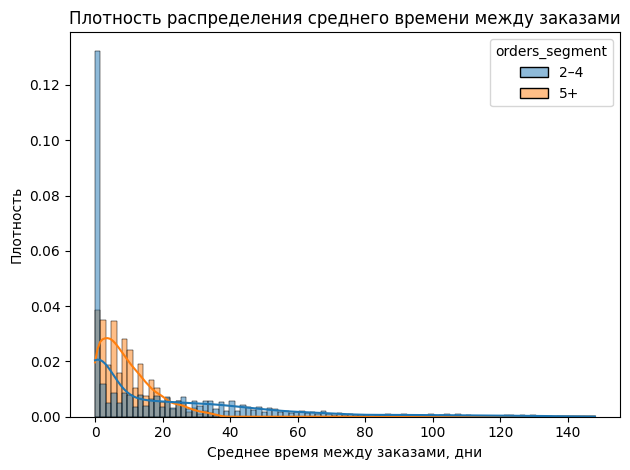

In [185]:
sns.histplot(
    data=segmented,
    x='avg_time_between_orders_days',
    hue='orders_segment',
    kde=True, stat='density',
)

plt.title('Плотность распределения среднего времени между заказами')
plt.xlabel('Среднее время между заказами, дни')
plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

- мало информативно, надо отсеять данные с малым количеством дней между покупками

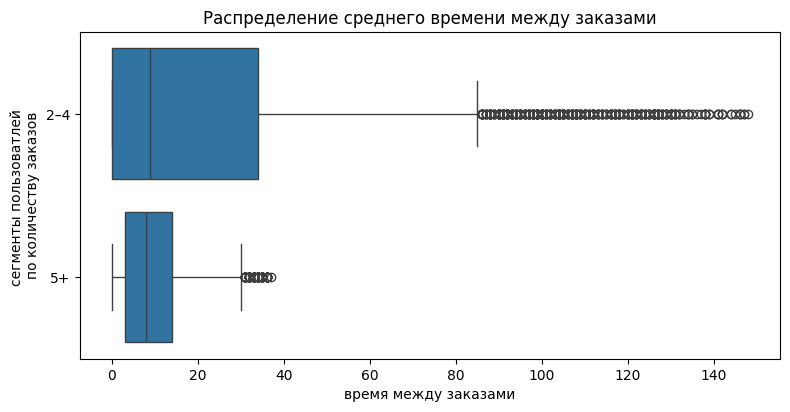

,orders_segment,avg_time_between_orders_days
0,2–4,9.0
1,5+,8.0


In [186]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=segmented, x='avg_time_between_orders_days', y='orders_segment', ax=ax)
ax.set_xlabel('время между заказами')
ax.set_ylabel('сегменты пользоватлей \nпо количеству заказов')
plt.tight_layout()
plt.title(f'Распределение среднего времени между заказами')
plt.show()

segmented.groupby('orders_segment')['avg_time_between_orders_days'].median().reset_index()

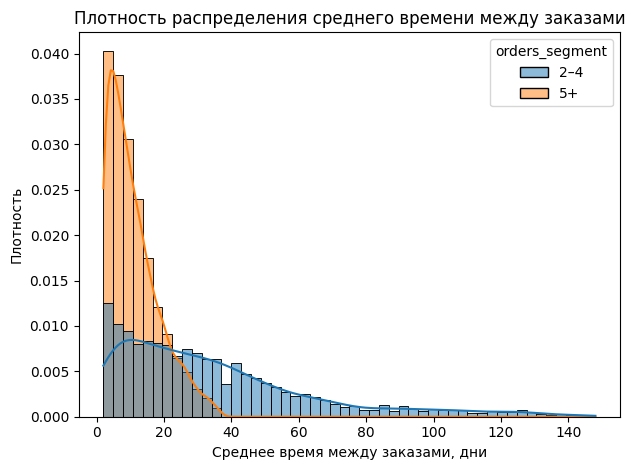

In [187]:
# отфильтруем данные с малым количеством дней между заказами
segmented_flt = segmented[segmented['avg_time_between_orders_days'] > 1]
sns.histplot(
    data=segmented_flt,
    x='avg_time_between_orders_days',
    hue='orders_segment',
    kde=True, stat='density',
    bins=50
)

plt.title('Плотность распределения среднего времени между заказами')
plt.xlabel('Среднее время между заказами, дни')
plt.ylabel('Плотность')
plt.tight_layout()
plt.show()


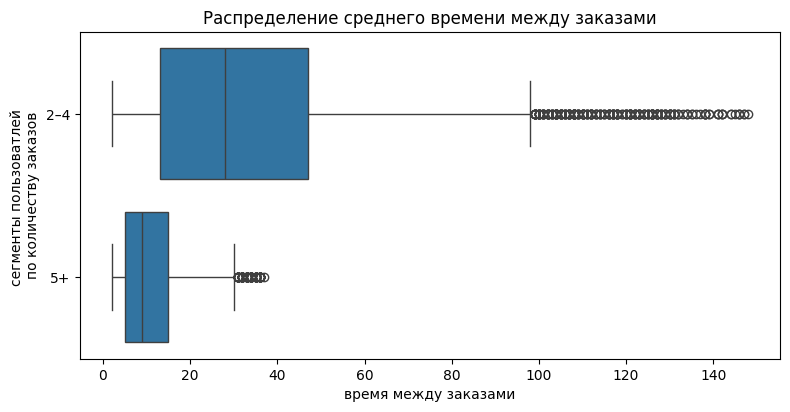

,orders_segment,avg_time_between_orders_days
0,2–4,28.0
1,5+,9.0


In [188]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=segmented_flt, x='avg_time_between_orders_days', y='orders_segment', ax=ax)
ax.set_xlabel('время между заказами')
ax.set_ylabel('сегменты пользоватлей \nпо количеству заказов')
plt.tight_layout()
plt.title(f'Распределение среднего времени между заказами')
plt.show()

segmented_flt.groupby('orders_segment')['avg_time_between_orders_days'].median().reset_index()

In [189]:
quantiles = (
    segmented_flt
        .groupby('orders_segment')['avg_time_between_orders_days']
        .quantile([0.25, 0.5, 0.75, 0.9, 0.95])
        .unstack()
        .rename(columns={
            0.25: 'Q25',
            0.5: 'Median',
            0.75: 'Q75',
            0.9: 'Q90',
            0.95: 'Q95'
        })
        .reset_index()
)

quantiles

,orders_segment,Q25,Median,Q75,Q90,Q95
0,2–4,13.0,28.0,47.0,75.0,100.0
1,5+,5.0,9.0,15.0,22.0,26.0


- убрав данные с малым количеством дней между заказами, получаем более наглядную картину:
    - медиана распределения среднего времени между заказами в группе 5+ равна 9, что существенно меньше, чем для сегмента 2-4 заказа - 28 дней.
    
### Промежуточный вывод:

- для сегмента 2-4 среднее время между заказами концентрируется в диапазоне 28-45 дней, медиана 28. Следовательно, если клиент этой категории вываливается из диапазона 45 дней, то стоит его простимулировать к покупке.
- для клиентов с 5+ заказами ситуация такая: Q25=5.0, Q50=9.0, Q75=15. Следуя этой же логике, надо стимулировать уже спустя 15 дней с момента последней покупки.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

---

**4.4.1:** корреляционный анализ

---

In [190]:
df_users_profile.head()

,user_id,first_order_device,first_order_id,first_order_ts,first_order_region_name,first_order_service_name,first_order_event_type_main,order_ts,total_order_count,avg_order_revenue,avg_order_tickets,avg_time_between_orders,is_two,is_five,avg_time_between_orders_days,avg_revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20 16:08:03,каменевский_регион,край_билетов,театр,2024-08-20 16:08:03,1,1521.940000,4.000000,NaT,False,False,NaN,380.485000
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23 18:36:24,каменевский_регион,мой_билет,выставки,2024-10-06 13:56:02,2,774.010000,3.000000,74 days 19:19:38,True,False,74.0,258.003333
2,000898990054619,mobile,1139875,2024-07-13 19:40:48,североярская_область,лови_билет,другое,2024-10-23 15:12:00,3,767.213333,2.666667,50 days 21:45:36,True,False,50.0,287.705000
3,00096d1f542ab2b,desktop,6636941,2024-08-15 16:48:48,каменевский_регион,край_билетов,театр,2024-08-15 16:48:48,1,917.830000,4.000000,NaT,False,False,NaN,229.457500
4,000a55a418c128c,mobile,4657981,2024-09-29 19:39:12,поленовский_край,лучшие_билеты,театр,2024-10-15 10:29:04,2,61.310000,1.500000,15 days 14:49:52,True,False,15.0,40.873333


In [191]:
profile_features = [
    'first_order_device', 
    'first_order_region_name', 
    'first_order_service_name', 'first_order_event_type_main',
    'total_order_count', 'avg_order_revenue', 'avg_order_tickets', 'avg_revenue_rub','avg_time_between_orders_days', 
    ]
numeric_columns = ['total_order_count', 'avg_order_revenue', 'avg_order_tickets', 'avg_revenue_rub','avg_time_between_orders_days']

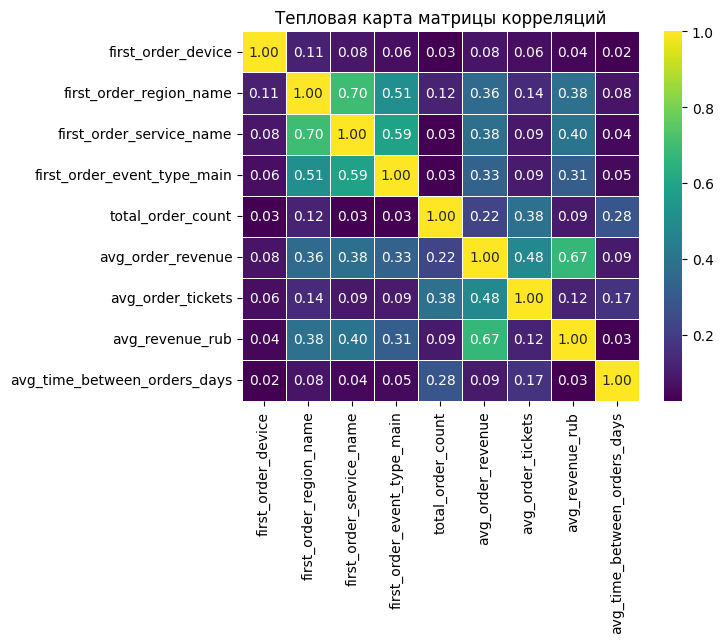

Корреляция переменных с 'total_order_count':
total_order_count               1.000000
avg_order_tickets               0.383913
avg_time_between_orders_days    0.284557
avg_order_revenue               0.219643
first_order_region_name         0.117353
avg_revenue_rub                 0.090951
first_order_event_type_main     0.028352
first_order_service_name        0.027352
first_order_device              0.027014
Name: total_order_count, dtype: float64


In [192]:
# Посчитаем матрицу корреляций
corr_matrix = df_users_profile[profile_features].phik_matrix(interval_cols=numeric_columns)

# Создаём тепловую  карту
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

# Показываем график с заголовком
plt.title('Тепловая карта матрицы корреляций')
plt.show()
print("Корреляция переменных с 'total_order_count':")
print(corr_matrix['total_order_count'].sort_values( ascending=False))

In [193]:
df_users_profile['total_order_count'].describe()

count    21428.000000
mean         6.539248
std         14.367341
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: total_order_count, dtype: float64

- корреляция близка к 0, поскольку в 'total_order_count' много значений 1 заказа
- введем сегментацию

In [194]:
# сегментация по total_order_count

def segment_total_orders(x: int) -> str:
    if x == 1:
        return '1'
    if 2 <= x <= 4:
        return '2–4'
    return '5+'


df_users_profile['total_order_count_segment'] = df_users_profile['total_order_count'].apply(segment_total_orders)

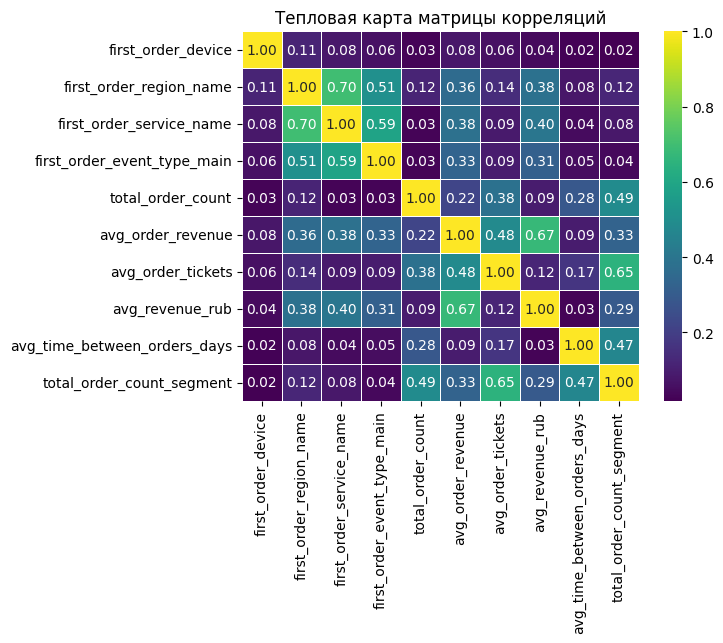

Корреляция переменных с 'total_order_count_segment':
total_order_count_segment       1.000000
avg_order_tickets               0.647372
total_order_count               0.487940
avg_time_between_orders_days    0.468247
avg_order_revenue               0.326120
avg_revenue_rub                 0.291908
first_order_region_name         0.124496
first_order_service_name        0.081904
first_order_event_type_main     0.040198
first_order_device              0.017635
Name: total_order_count_segment, dtype: float64


In [195]:
# Посчитаем матрицу корреляций
profile_features = list(dict.fromkeys(profile_features + ['total_order_count_segment']))
profile_features
corr_matrix = df_users_profile[profile_features].phik_matrix(interval_cols=numeric_columns)

# # Создаём тепловую  карту
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

# Показываем график с заголовком
plt.title('Тепловая карта матрицы корреляций')
plt.show()
print("Корреляция переменных с 'total_order_count_segment':")
print(corr_matrix['total_order_count_segment'].sort_values(ascending=False))

### Промежуточный вывод:

- после проведения сегментации по количеству заказов (1 заказ; от 2 до 4 заказов; от 5 и выше.) можно отметить существенную корреляцию количества заказов со средним числом купленных билетов в одном заказе на уровне 0.65 (максимальная связь именно с этим признаком). 
- исходя из предыдущих этапов анализа, можно отметить, что люди чаще делают повторные заказы со средним количеством 2-3 по билетам, нежели с 1 билетом. Значит, корреляция между этими признаками положительная.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

### Общий вывод и рекомендации:

**Данные и подготовка**
- Типы данных соответствуют описанию, выгрузка из SQL прошла успешно.
- Пропуски есть только в `days_since_prev` (7.5%) — оставлены без удаления.
- В `revenue` и `revenue_rub` выявлены отрицательные значения (<0.2%) — строки удалены.
- Отсутствующая информация: `event_type_main` — 22.6%.
- Проведено понижение размерностей в `order_id`, `tickets_count`, `event_id`, `days_since_prev`, `revenue`, `revenue_rub`. Уменьшена избыточность `order_dt`.
- Нормализация тестовых данных в `region_name`, `city_name`, `service_name`.
- Добавлен столбец `revenue_rub`.
- Обнаружены выбросы в `revenue_rub`, `tickets_count`, `days_since_prev`. Фильтрация по 99‑му перцентилю для `revenue_rub` дала потери 0.97%. В профиле пользователя дополнительно отфильтрованы выбросы по 99‑му перцентилю для количества заказов и среднего числа билетов, потери 1.88%. Выбросы по `days_since_prev` учитываются в интерпретации.
- Дубликаты не выявлены.

**Ключевые результаты анализа**

Структура пользователей
- 38% пользователей сделали только 1 заказ
- 61,7% сделали 2+ заказов
- 29% сделали 5+ заказов
- Медианное число заказов — 2
- Средняя выручка с заказа — 545 руб.
    
*Повторные покупки*

    На вероятность возврата влияют:

    1. Количество билетов в заказе

    - Самая сильная связь с числом заказов (корреляция 0.65)
    - Сегмент 2–3 билета — доля повторных покупок 74%
    - Сегмент 1–2 билета — только 40%
    Чем больше билетов в первом заказе, тем выше вероятность возврат

    2. Средний чек

    - Медианный чек у пользователей с 2+ заказами выше на 12,5%
    - У сегмента 5+ заказов медиана выше на 8,2% относительно сегмента 2–4
    Более высокий чек связан с более высокой вероятностью повторных покупок.
    
    3. Тип первого мероприятия

    Разница в возврате между типами мероприятий достигает 8%.
    Тип мероприятия оказывает умеренное влияние.
    
    4. Интервалы между покупками

    - Сегмент 2–4 заказа:

        Q50 = 28 дней

        Q75 = 45 дней

    - Сегмент 5+ заказов:

        Q50 = 9 дней

        Q75 = 15 дней

    Лояльные клиенты имеют значительно более короткий цикл повторной покупки.
    
    На вероятность повторной покупки мало влияют:
    1. Регион
    - Корреляция между популярностью региона и долей повторных покупок: -0.31
    - В более популярных регионах возврат немного ниже, но связь слабая.
    
    2. Устройство
    - Компьютер — 64% повторных заказов
    - Мобильные — 61%
    Разница небольшая
    
  

**Рекомендации**
1. Работать с сегментом 1–2 билета: Низкая доля повторных покупок (40%) по сравнению с сегментом 2-3 билета (74%).
   Рекомендуется сделать акцию, стимулирующую покупку большего количества билетов в заказ.
2. Повышать средний чек. Анализ подтвердил положительную связь повторных заказов со средним чеком.
3. Настроить напоминания о сервисе в зависимости от сегмента клиента по количеству совершенных заказов:
    - Для сегмента 2–4 заказов: Стимулировать после 45 дней без заказа
    - Для сегмента 5+ заказов: Стимулировать уже после 15 дней
4. Необходимо приоритезировать удержание пользователей: 38% пользователей — заказали лишь один раз.
